# Mueller Matrix Tissue Segmentation
**Classes:**
- Class 0: Background
- Class 1: Tissue (general)
- Class 2: OS
- Class 3: Vaginal

**Before running:**
1. Update `DATA_DIR`
2. Adjust `BATCH_SIZE` based on GPU

## 1. Imports and Setup

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm
import json
import logging
import ssl
import warnings
import platform
import random

warnings.filterwarnings('ignore')
ssl._create_default_https_context = ssl._create_unverified_context

# Reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

print("Imports successful")

Imports successful


## 2. Configuration

In [36]:
class Config:
    """Configuration"""

    # === PATHS ===
    DATA_DIR = Path("F:/MPL_Data/mmNoTissueFilter/TRIMMM")
    OUTPUT_DIR = Path("../../models/robust_normalization")

    # === MODEL ===
    ENCODER_NAME = 'resnet34'
    USE_PRETRAINED = True

    # === TRAINING ===
    BATCH_SIZE = 8
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 15

    # === DATA STRATEGY ===
    # Groups to completely isolate (Not Train, Not Val, Not Test)
    # These are for your final "Hard Check"
    ISOLATED_SAMPLES = [
        'Day6_mm_results_Day6E_4B_S2',
        'Day6_mm_results_day6_3',
        'Day0_mm_results_Day0G_7B_S3',
        'Day0_mm_results_Day0H_3B_S6'
    ]

    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    RANDOM_SEED = 42
    INPUT_SIZE = (512, 512)

    # New Augmentation Settings
    INTENSITY_JITTER = 0.15  # +/- 15% brightness variation

    # === GPU ===
    USE_GPU = True
    USE_MIXED_PRECISION = True
    NUM_WORKERS = 0

    if USE_GPU and torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        DEVICE = torch.device('cpu')
        print("Using CPU")

set_seed(Config.RANDOM_SEED)
Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Using GPU: NVIDIA RTX 5000 Ada Generation Laptop GPU


## 3. Data Loading & Parsing

In [39]:
def discover_samples(data_dir: Path) -> List[Dict]:
    """Discover samples and identify their parent groups"""
    if not data_dir.exists():
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    samples = []
    parent_dirs = [d for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith('.')]

    print(f"Scanning {len(parent_dirs)} parent directories...")

    for parent_dir in parent_dirs:
        # Group samples by the parent folder (e.g., 'Day6', 'Day0')
        # This is crucial for the Group Split
        group_id = parent_dir.name

        sample_dirs = [d for d in parent_dir.iterdir() if d.is_dir() and not d.name.startswith('.')]

        # Group variations (rot/flip) under one unique sample name
        sample_groups = {}
        for sample_dir in sample_dirs:
            name = sample_dir.name
            base_name = name
            for suffix in ['_original', '_rot90', '_rot180', '_rot270', '_flip_h', '_flip_v']:
                base_name = base_name.replace(suffix, '')

            unique_name = f"{parent_dir.name}_{base_name}"

            if unique_name not in sample_groups:
                sample_groups[unique_name] = []
            sample_groups[unique_name].append(sample_dir)

        for unique_name, dirs in sample_groups.items():
            # Only pick the _original folder
            selected_dir = next((d for d in dirs if '_original' in d.name), dirs[0])
            npz_files = [f for f in selected_dir.glob("*.npz") if not f.name.startswith('.')]

            if npz_files:
                samples.append({
                    'sample_name': unique_name,
                    'group_id': group_id,  # Used for splitting
                    'npz_path': npz_files[0]
                })

    return samples

def extract_m11_and_mask(npz_path: Path) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """Extract M11 and Mask. Normalizes M11 to 0-1 range."""
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            # 1. Get M11
            m11 = None
            if 'nM11s' in data: m11 = np.array(data['nM11s'])
            elif 'M11s' in data:
                m11_raw = np.array(data['M11s'])
                # Min-Max normalize to 0-1
                if m11_raw.max() > m11_raw.min():
                    m11 = (m11_raw - m11_raw.min()) / (m11_raw.max() - m11_raw.min())
                else:
                    m11 = np.zeros_like(m11_raw)

            if m11 is None or m11.ndim != 2: return None

            # 2. Get Masks
            tissue_mask = None
            for key in ['tissue_mask', 'annotation_mask']:
                if key in data: tissue_mask = np.array(data[key]) > 0; break

            if tissue_mask is None: return None

            os_mask = np.array(data['os_mask']) > 0 if 'os_mask' in data else None
            
            # Vaginal mask - check multiple possible keys
            vag_mask = None
            for key in ['vaginal_mask', 'vaginal_wall', 'vaginal_wall_mask']:
                if key in data:
                    vag_mask = np.array(data[key]) > 0
                    break

            # 3. Combine Priorities: Vaginal(3) > OS(2) > Tissue(1) > Bg(0)
            combined_mask = np.zeros_like(tissue_mask, dtype=np.int64)
            combined_mask[tissue_mask] = 1
            if os_mask is not None: combined_mask[os_mask] = 2
            if vag_mask is not None: combined_mask[vag_mask] = 3

            return m11.astype(np.float32), combined_mask.astype(np.int64)
    except:
        return None

print("Data functions defined")

Data functions defined


## 4. Dataset Class with ImageNet Normalization & Augmentation

In [40]:
class M11Dataset(Dataset):
    def __init__(self, samples, input_size=(512, 512), augment=False, intensity_jitter=0.0):
        self.samples = samples
        self.input_size = input_size
        self.augment = augment
        self.intensity_jitter = intensity_jitter

        # ImageNet normalization (matching inference preprocessing)
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)

        # Pre-load to save time
        self.data = []
        for s in tqdm(samples, desc="Loading Cache"):
            res = extract_m11_and_mask(s['npz_path'])
            if res: self.data.append(res)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        m11, mask = self.data[idx]

        # Resize
        m11 = self._resize(m11, is_mask=False)
        mask = self._resize(mask, is_mask=True)

        # Augmentation
        if self.augment:
            # Geometric
            if np.random.rand() > 0.5: # Flip H
                m11 = np.fliplr(m11); mask = np.fliplr(mask)
            if np.random.rand() > 0.5: # Flip V
                m11 = np.flipud(m11); mask = np.flipud(mask)
            k = np.random.randint(0, 4) # Rotate
            if k > 0:
                m11 = np.rot90(m11, k); mask = np.rot90(mask, k)

            # Intensity (Brightness) Augmentation
            # This helps the model handle different exposure levels in isolated samples
            if self.intensity_jitter > 0:
                # Random factor between (1-jitter) and (1+jitter)
                factor = 1.0 + np.random.uniform(-self.intensity_jitter, self.intensity_jitter)
                m11 = m11 * factor
                # Clip to keep it reasonable
                m11 = np.clip(m11, 0.0, 1.0)

        # Convert to 3 channels (replicate grayscale)
        m11_rgb = np.stack([m11, m11, m11], axis=0)  # [3, H, W]

        # ImageNet normalization: (x - mean) / std
        m11_normalized = (m11_rgb - self.mean) / self.std

        m11_tensor = torch.from_numpy(m11_normalized).float()

        return m11_tensor, torch.from_numpy(mask.copy()).long()

    def _resize(self, img, is_mask):
        t = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)
        if is_mask:
            res = F.interpolate(t, size=self.input_size, mode='nearest')
        else:
            res = F.interpolate(t, size=self.input_size, mode='bilinear', align_corners=True)
        return res.squeeze().numpy().astype(np.int64 if is_mask else np.float32)

print("Dataset class defined (using ImageNet normalization)")

Dataset class defined (using ImageNet normalization)


## 5. Prepare Data (Stratified Split - Balanced Days)

In [41]:
from sklearn.model_selection import StratifiedShuffleSplit

all_samples = discover_samples(Config.DATA_DIR)

# 1. Remove Isolated Samples first
dataset_samples = []
isolated_data = []

for s in all_samples:
    if s['sample_name'] in Config.ISOLATED_SAMPLES:
        isolated_data.append(s)
    else:
        dataset_samples.append(s)

print(f"\nTotal Dataset Samples: {len(dataset_samples)}")
print(f"Isolated Samples (Saved for later): {len(isolated_data)}")

# 2. Perform Stratified Split
# We split based on 'group_id' (Day) to ensure every Day is represented in Train and Test
groups = [s['group_id'] for s in dataset_samples]

# Split 1: Separate Train vs Temp (Val+Test)
# This ensures 70% of Day0 is in Train, 30% of Day0 is in Temp
splitter = StratifiedShuffleSplit(n_splits=1, test_size=Config.VAL_RATIO + Config.TEST_RATIO, random_state=Config.RANDOM_SEED)
train_idx, temp_idx = next(splitter.split(dataset_samples, groups))

train_subset = [dataset_samples[i] for i in train_idx]
temp_subset = [dataset_samples[i] for i in temp_idx]

# Split 2: Separate Val vs Test
# Get groups for the temp subset to stratify again
temp_groups = [temp_subset[i]['group_id'] for i in range(len(temp_subset))]

splitter_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=Config.RANDOM_SEED)
val_idx, test_idx = next(splitter_val.split(temp_subset, temp_groups))

val_subset = [temp_subset[i] for i in val_idx]
test_subset = [temp_subset[i] for i in test_idx]

print(f"Train: {len(train_subset)} samples")
print(f"Val:   {len(val_subset)} samples")
print(f"Test:  {len(test_subset)} samples")

# 3. Create Datasets (using ImageNet normalization - no need to calculate custom stats)
print("\nUsing ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])")

train_ds = M11Dataset(train_subset, augment=True, intensity_jitter=Config.INTENSITY_JITTER)
val_ds = M11Dataset(val_subset, augment=False)
test_ds = M11Dataset(test_subset, augment=False)

# Loaders
train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=Config.BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=Config.BATCH_SIZE)

print("\n" + "="*60)
print("TEST SET MANIFEST (Balanced across Days)")
print("="*60)
# Sort by group to see the balance clearly
sorted_test = sorted(test_subset, key=lambda x: x['group_id'])
for s in sorted_test:
    print(f"Group: {s['group_id']} | Sample: {s['sample_name']}")
print("="*60)

Scanning 7 parent directories...

Total Dataset Samples: 70
Isolated Samples (Saved for later): 4
Train: 49 samples
Val:   10 samples
Test:  11 samples

Using ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


Loading Cache: 100%|██████████| 11/11 [00:00<00:00, 22.69it/s]


TEST SET MANIFEST (Balanced across Days)
Group: Day0 | Sample: Day0_mm_results_Day0G_9B_S4
Group: Day12 | Sample: Day12_mm_results_day12_1
Group: Day12 | Sample: Day12_mm_results_Day12D_7B_S3
Group: Day13 | Sample: Day13_mm_results_D13D_S9A_5
Group: Day14 | Sample: Day14_mm_results_D14D_S8A_3
Group: Day15 | Sample: Day15_mm_results_D15C_S5A_2
Group: Day15 | Sample: Day15_mm_results_D15E_S9B_6
Group: Day15 | Sample: Day15_mm_results_D15E_S7B_4
Group: Day15 | Sample: Day15_mm_results_D15F_S6B_5
Group: Day18 | Sample: Day18_mm_results_day18_2
Group: Day6 | Sample: Day6_mm_results_day6_1


## 6. Model & Training Components

In [42]:
class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Using simple ResNet34
        self.encoder = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        self.enc_layers = list(self.encoder.children())

        self.enc1 = nn.Sequential(*self.enc_layers[:3]) # 64
        self.enc2 = nn.Sequential(*self.enc_layers[3:5]) # 64
        self.enc3 = self.enc_layers[5] # 128
        self.enc4 = self.enc_layers[6] # 256
        self.enc5 = self.enc_layers[7] # 512

        self.dec4 = self._block(512 + 256, 256)
        self.dec3 = self._block(256 + 128, 128)
        self.dec2 = self._block(128 + 64, 64)
        self.dec1 = self._block(64 + 64, 32)

        self.final = nn.Conv2d(32, num_classes, 1)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c), nn.ReLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        d4 = F.interpolate(e5, size=e4.shape[2:], mode='bilinear')
        d4 = self.dec4(torch.cat([d4, e4], 1))

        d3 = F.interpolate(d4, size=e3.shape[2:], mode='bilinear')
        d3 = self.dec3(torch.cat([d3, e3], 1))

        d2 = F.interpolate(d3, size=e2.shape[2:], mode='bilinear')
        d2 = self.dec2(torch.cat([d2, e2], 1))

        d1 = F.interpolate(d2, size=e1.shape[2:], mode='bilinear')
        d1 = self.dec1(torch.cat([d1, e1], 1))

        out = F.interpolate(d1, scale_factor=2, mode='bilinear')
        return self.final(out)

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()

    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)

        # Simple Dice
        pred_soft = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1]).permute(0,3,1,2)

        intersection = (pred_soft * target_one_hot).sum(dim=(2,3))
        union = pred_soft.sum(dim=(2,3)) + target_one_hot.sum(dim=(2,3))
        dice_score = (2. * intersection + 1) / (union + 1)
        dice_loss = 1 - dice_score.mean()

        return 0.5 * ce_loss + 0.5 * dice_loss

# Determine classes
temp_loader = DataLoader(train_ds, batch_size=1)
_, mask_sample = next(iter(temp_loader))
num_classes = 4 # Known from config
print(f"Initializing model for {num_classes} classes...")

model = UNet(num_classes).to(Config.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
criterion = CombinedLoss()
scaler = GradScaler()

Initializing model for 4 classes...


## 7. Training Loop with Loss & Accuracy Tracking

In [43]:
def calculate_accuracy(pred, target):
    """Calculate pixel-wise accuracy"""
    pred_class = torch.argmax(pred, dim=1)
    correct = (pred_class == target).sum().item()
    total = target.numel()
    return correct / total

best_loss = float('inf')
best_acc = 0.0

for epoch in range(Config.NUM_EPOCHS):
    model.train()
    train_loss = 0
    train_acc = 0

    for img, mask in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)

        optimizer.zero_grad()
        with autocast():
            pred = model(img)
            if pred.shape[-2:] != mask.shape[-2:]:
                pred = F.interpolate(pred, size=mask.shape[-2:])
            loss = criterion(pred, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        train_acc += calculate_accuracy(pred, mask)

    # Validation
    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)
            pred = model(img)
            if pred.shape[-2:] != mask.shape[-2:]:
                pred = F.interpolate(pred, size=mask.shape[-2:])
            val_loss += criterion(pred, mask).item()
            val_acc += calculate_accuracy(pred, mask)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_acc / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_acc = avg_val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': {
                'encoder_name': Config.ENCODER_NAME,
                'num_classes': num_classes,
                'input_size': Config.INPUT_SIZE
            },
            'epoch': epoch + 1,
            'val_loss': avg_val_loss,
            'val_acc': avg_val_acc
        }, Config.OUTPUT_DIR / 'best_model.pth')
        print(f"✓ Saved new best model (Val Acc: {avg_val_acc:.4f})")

print(f"\nTraining complete! Best Val Loss: {best_loss:.4f} | Best Val Acc: {best_acc:.4f}")

Epoch 1: 100%|██████████| 7/7 [00:01<00:00,  6.15it/s]


Epoch 1 | Train Loss: 0.9897 | Train Acc: 0.4305 | Val Loss: 1.0884 | Val Acc: 0.2875
✓ Saved new best model (Val Acc: 0.2875)


Epoch 2: 100%|██████████| 7/7 [00:00<00:00,  8.59it/s]


Epoch 2 | Train Loss: 0.8304 | Train Acc: 0.6535 | Val Loss: 1.0618 | Val Acc: 0.2904
✓ Saved new best model (Val Acc: 0.2904)


Epoch 3: 100%|██████████| 7/7 [00:00<00:00,  8.48it/s]


...

Epoch 48 | Train Loss: 0.3478 | Train Acc: 0.9255 | Val Loss: 0.4591 | Val Acc: 0.8794


Epoch 49: 100%|██████████| 7/7 [00:00<00:00,  8.71it/s]


Epoch 49 | Train Loss: 0.3550 | Train Acc: 0.9319 | Val Loss: 0.4555 | Val Acc: 0.8864


Epoch 50: 100%|██████████| 7/7 [00:00<00:00,  8.39it/s]


Epoch 50 | Train Loss: 0.3352 | Train Acc: 0.9321 | Val Loss: 0.4490 | Val Acc: 0.8830
✓ Saved new best model (Val Acc: 0.8830)

Training complete! Best Val Loss: 0.4490 | Best Val Acc: 0.8830


## 8. Evaluation on Test Set & Isolated Samples

**Metrics:**
- Overall Accuracy: Percentage of correctly classified pixels
- Per-Class IoU (Intersection over Union): Measures overlap for each class
- Mean IoU: Average IoU across all classes


Evaluating Test Set...


Test Inference: 100%|██████████| 2/2 [00:00<00:00,  3.96it/s]



TEST SET RESULTS
Overall Accuracy: 90.55%

Per-Class IoU:
  Class 0 (Background): 88.82%
  Class 1 (Tissue    ): 82.91%
  Class 2 (OS        ): 74.32%
  Class 3 (Vaginal   ): 70.79%

Mean IoU: 79.21%

Visualizing Test Set Sample (In-Distribution):


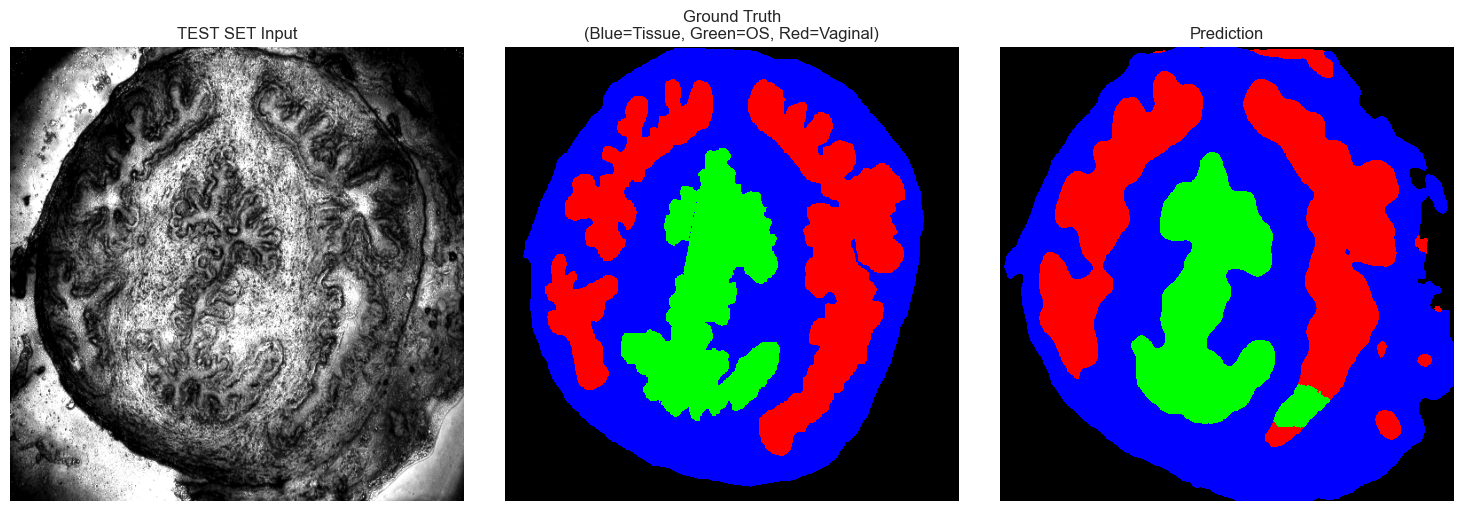


Visualizing Isolated Samples (Out-of-Distribution Check):


Loading Cache: 100%|██████████| 4/4 [00:00<00:00, 13.26it/s]



Evaluating Isolated Set...


Isolated Inference: 100%|██████████| 1/1 [00:00<00:00, 19.56it/s]



ISOLATED SET RESULTS
Overall Accuracy: 90.66%

Per-Class IoU:
  Class 0 (Background): 92.39%
  Class 1 (Tissue    ): 80.26%
  Class 2 (OS        ): 69.55%
  Class 3 (Vaginal   ): 68.71%

Mean IoU: 77.73%

Isolated Sample: Day6_mm_results_day6_3


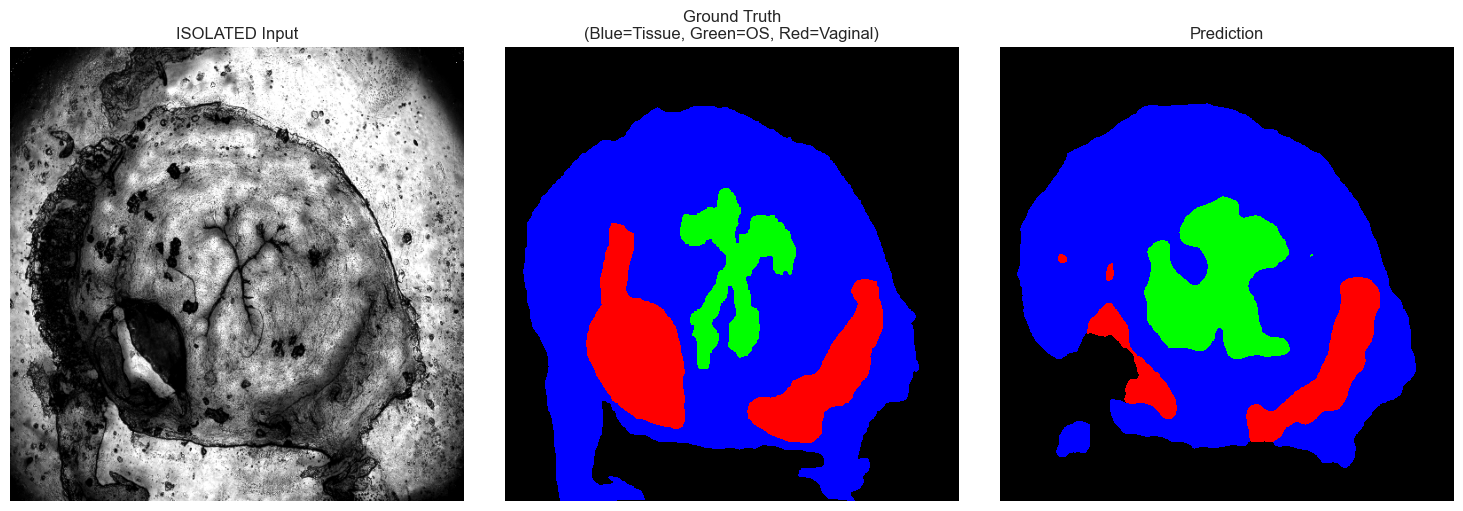

Isolated Sample: Day6_mm_results_Day6E_4B_S2


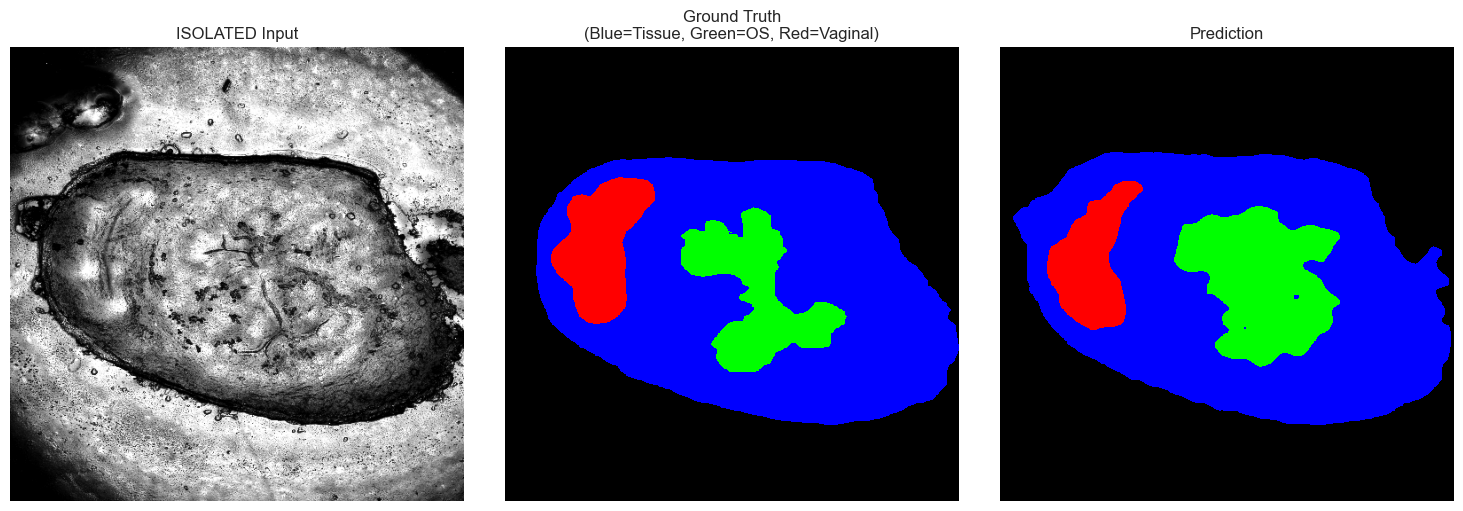

Isolated Sample: Day0_mm_results_Day0G_7B_S3


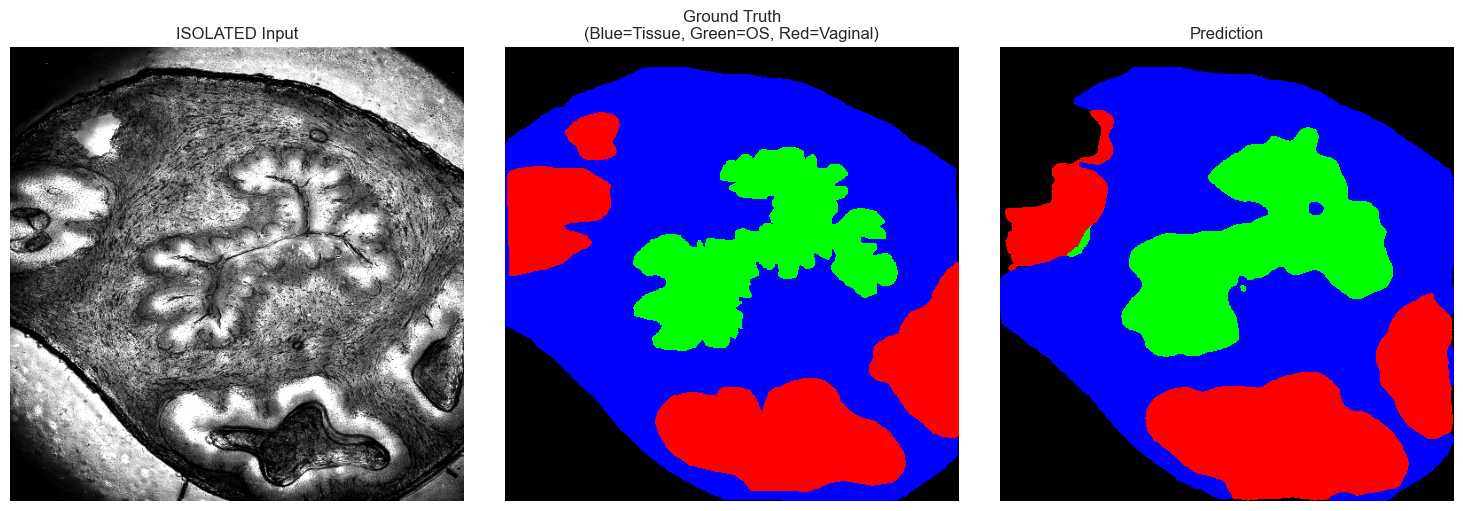

In [45]:
model.load_state_dict(torch.load(Config.OUTPUT_DIR / 'best_model.pth')['model_state_dict'])
model.eval()

# ==================== METRICS CALCULATION ====================

def calculate_metrics(loader, dataset_name="Test"):
    """Calculate comprehensive metrics"""
    all_preds = []
    all_targets = []
    
    print(f"\nEvaluating {dataset_name} Set...")
    with torch.no_grad():
        for img, mask in tqdm(loader, desc=f"{dataset_name} Inference"):
            img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)
            pred = model(img)
            if pred.shape[-2:] != mask.shape[-2:]:
                pred = F.interpolate(pred, size=mask.shape[-2:])
            pred_class = torch.argmax(pred, dim=1)
            
            all_preds.append(pred_class.cpu().numpy())
            all_targets.append(mask.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    # Overall Accuracy
    accuracy = (all_preds == all_targets).mean()
    
    # Per-Class IoU
    class_names = ['Background', 'Tissue', 'OS', 'Vaginal']
    ious = []
    
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} SET RESULTS")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {accuracy*100:.2f}%")
    print(f"\nPer-Class IoU:")
    
    for class_id in range(num_classes):
        pred_mask = (all_preds == class_id)
        true_mask = (all_targets == class_id)
        
        intersection = (pred_mask & true_mask).sum()
        union = (pred_mask | true_mask).sum()
        
        if union > 0:
            iou = intersection / union
        else:
            iou = float('nan')
        
        ious.append(iou)
        print(f"  Class {class_id} ({class_names[class_id]:10s}): {iou*100:.2f}%" if not np.isnan(iou) else f"  Class {class_id} ({class_names[class_id]:10s}): N/A (not present)")
    
    # Mean IoU (excluding NaN values)
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    mean_iou = np.mean(valid_ious) if valid_ious else 0.0
    print(f"\nMean IoU: {mean_iou*100:.2f}%")
    print(f"{'='*60}\n")
    
    return accuracy, ious, mean_iou

# Evaluate Test Set
test_acc, test_ious, test_miou = calculate_metrics(test_loader, "Test")

# ==================== VISUALIZATION ====================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define colormap: 0=Black, 1=Blue, 2=Lime, 3=Red
cmap_colors = ['black', 'blue', 'lime', 'red']
cmap = mcolors.ListedColormap(cmap_colors)
norm = mcolors.BoundaryNorm([0, 1, 2, 3, 4], cmap.N)

# ImageNet stats for denormalization
imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
imagenet_std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def visualize_prediction(dataset, idx, title_prefix=""):
    img_tensor, mask_true = dataset[idx]

    # Run Inference
    with torch.no_grad():
        input_tensor = img_tensor.unsqueeze(0).to(Config.DEVICE)
        pred = model(input_tensor)
        if pred.shape[-2:] != mask_true.shape[-2:]:
            pred = F.interpolate(pred, size=mask_true.shape[-2:])
        pred_mask = torch.argmax(pred, dim=1).cpu().squeeze().numpy()

    # Denormalize image for display
    # Reverse ImageNet normalization: (x * std) + mean
    img_np = img_tensor.numpy()  # [3, H, W]
    img_denorm = img_np * imagenet_std.reshape(3, 1, 1) + imagenet_mean.reshape(3, 1, 1)
    img_disp = img_denorm[0]  # Use first channel (all 3 are identical)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Input M11
    ax[0].imshow(img_disp, cmap='gray')
    ax[0].set_title(f"{title_prefix} Input")
    ax[0].axis('off')

    # 2. Ground Truth
    ax[1].imshow(mask_true, cmap=cmap, norm=norm, interpolation='nearest')
    ax[1].set_title("Ground Truth\n(Blue=Tissue, Green=OS, Red=Vaginal)")
    ax[1].axis('off')

    # 3. Prediction
    ax[2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation='nearest')
    ax[2].set_title("Prediction")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Visualizing Test Set Sample (In-Distribution):")
if len(test_ds) > 0:
    visualize_prediction(test_ds, 0, "TEST SET")

print("\nVisualizing Isolated Samples (Out-of-Distribution Check):")
# Create a temp dataset for isolated samples using ImageNet normalization
isolated_ds = M11Dataset(isolated_data, augment=False)

if len(isolated_ds) > 0:
    # Evaluate isolated samples
    isolated_loader = DataLoader(isolated_ds, batch_size=Config.BATCH_SIZE)
    isolated_acc, isolated_ious, isolated_miou = calculate_metrics(isolated_loader, "Isolated")
    
    # Visualize
    for i in range(min(3, len(isolated_ds))):
        name = isolated_data[i]['sample_name']
        print(f"Isolated Sample: {name}")
        visualize_prediction(isolated_ds, i, "ISOLATED")
else:
    print("No isolated samples found.")